# 0.0 Set up

In [1]:
!pip install -qq osmium

In [2]:
import re
import time
import json
import os, sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path 
import geopandas as gpd
import osmnx as ox
import osmium

from shapely.validation import make_valid
from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry import LineString, shape, mapping
from shapely.prepared import prep
from shapely.strtree import STRtree
from collections import OrderedDict
# import igraph as ig

# Add project root to Python path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
  sys.path.insert(0, str(project_root))

# Import config and setup
from config import setup_notebook, get_path
setup_notebook()

✓ Project root: /workspace/project_paaral
✓ Working directory: /workspace/project_paaral
✓ Python path updated


{'project_root': PosixPath('/workspace/project_paaral'),
 'data': PosixPath('/workspace/project_paaral/data'),
 'modules': PosixPath('/workspace/project_paaral/modules'),
 'notebooks': PosixPath('/workspace/project_paaral/notebooks'),
 'output': PosixPath('/workspace/project_paaral/output'),
 'psgc_shapefiles': PosixPath('/workspace/project_paaral/data/philippines-psgc-shapefiles/dist')}

# 1.0 Module

## 1.1 Load modules

In [3]:
from modules import psgc_consolidator
# Reload the module
importlib.reload(psgc_consolidator)

from modules import regional_road_network_extractor
# Reload the module
importlib.reload(regional_road_network_extractor)

<module 'modules.regional_road_network_extractor' from '/workspace/project_paaral/modules/regional_road_network_extractor.py'>

In [4]:
from modules.psgc_consolidator import PSGCConsolidator

In [5]:
# print(regional_road_network_extractor.__doc__)

In [6]:
# # Load geographic data (or shapefiles)
# consolidator = PSGCConsolidator(
#   base_path=get_path('psgc_shapefiles'),
#   verbose=False
# )
# gdf = consolidator.process()

In [7]:
# print(gdf.shape)
# display(gdf.head(2))

## 2.0 Query road network
Extract `drive` regional road networks for a region with provincial breakdown

### 2.1 Query one province
We use the `pyosmium` library to get bits and pieces from our Philippines OSM .PBF file that was downloaded from <a href="https://download.geofabrik.de/asia/philippines.html">GeoFabrik</a>.

#### Helper functions

In [9]:
# load your city polygon (GeoJSON FeatureCollection with 1 feature)
keep = {"motorway","trunk","primary","secondary","tertiary","unclassified","residential","service","road"}

class Roads(osmium.SimpleHandler):
    def __init__(self, poly, out_path):
        super().__init__()
        self.poly = poly
        self.out = open(out_path, "w", buffering=1024*1024)

    def way(self, w):
        h = w.tags.get("highway")
        if not h or h not in keep or len(w.nodes) < 2:
            return
        line = LineString([(n.lon, n.lat) for n in w.nodes])
        if not self.poly.intersects(line):
            return
        feat = {"type":"Feature",
                "geometry": mapping(line),
                "properties": {"highway": h, "name": w.tags.get("name")}}
        self.out.write(json.dumps(feat) + "\n")

    def close(self): self.out.close()

In [19]:
%%time
# Bulacan province, Region III
mask_province = gdf['psgc_code'].astype('string').str.contains(r'^03014')
prov_geom = gdf.loc[mask_province].union_all() # polygon

# Initialize and insert polygon of locality
h = Roads(prov_geom, "output/sjdm_drive_province.geojsonl")

# 'sparse_mmap_array' minimizes RAM on Windows
pbf_path = "data/networks/philippines-251002.osm.pbf"
h.apply_file(pbf_path, locations=True, idx="sparse_mmap_array")
h.close()

CPU times: user 1min 23s, sys: 2.57 s, total: 1min 25s
Wall time: 1min 19s


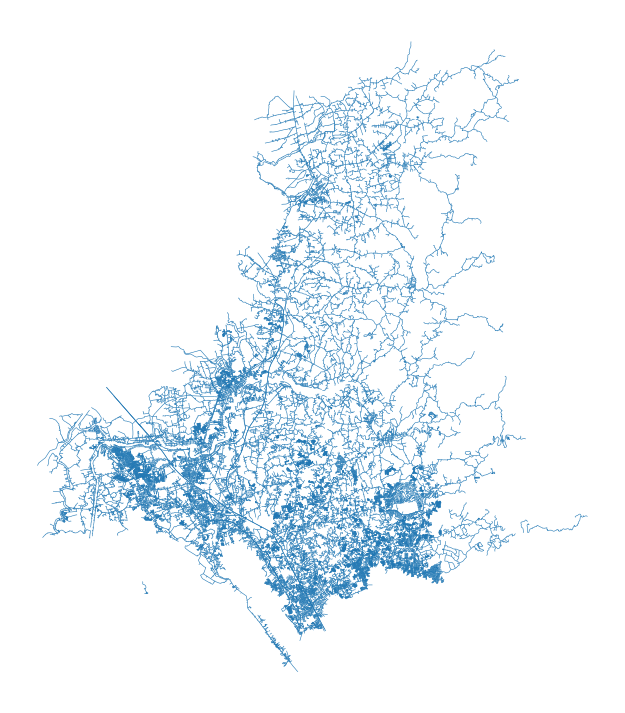

In [20]:
# Plot extracted road network of chosen province
# Note the GeoJSONSeq: prefix so GDAL/pyogrio uses the right driver
gdf = gpd.read_file(
    "GeoJSONSeq:output/sjdm_drive_province.geojsonl",
    engine="pyogrio"
)

ax = gdf.plot(figsize=(9,9), linewidth=0.4)
ax.set_aspect("equal")
ax.axis("off")

plt.show()

### 2.2 Query provinces

In [32]:
!ls -la data/networks/philippines-251002.osm.pbf

-rwxrwxrwx 1 root root 581439934 Oct  3 01:31 data/networks/philippines-251002.osm.pbf


#### 2.2.1 Pipeline

In [8]:
# === Paths (EDIT THESE) ===
PBF_PATH = "data/networks/philippines-251002.osm.pbf"
PROVINCES_PATH = "output/consolidated_geodata.gpkg"   # any vector file w/ province polygons
OUT_DIR = "output/province_road_networks"            # output folder (created if missing)

# === Behavior toggles ===
DO_CLIP = False           # False = intersect-only (faster/less RAM). True = clip to province boundary.
MAX_OPEN_FILES = 16       # cap on simultaneously open province files (keeps Windows happy)

# Optional: restrict to specific province slugs while testing (set to None to process all)
PROVINCE_WHITELIST = None
# e.g. PROVINCE_WHITELIST = {"bulacan", "cavite"}

# Highway tags we consider "driving"
DRIVE_HIGHWAYS = {
    "motorway","trunk","primary","secondary","tertiary",
    "unclassified","residential","service","road",
    "motorway_link","trunk_link","primary_link","secondary_link","tertiary_link"
}

In [9]:
def slugify(text: str) -> str:
    text = (text or "").strip().lower()
    text = re.sub(r"[^\w\s-]", "", text)
    text = re.sub(r"\s+", "-", text)
    text = re.sub(r"-{2,}", "-", text)
    return text or "unknown"

class LRUWriters:
    """
    Keep a small LRU cache of open file handles (slug -> .geojsonl), 
    auto-closing the least recently used when the limit is exceeded.
    """
    def __init__(self, out_dir: str, max_open: int = 16):
        self.out_dir = out_dir
        os.makedirs(out_dir, exist_ok=True)
        self.max_open = max_open
        self._open = OrderedDict()  # slug -> file handle

    def get(self, slug: str):
        if slug in self._open:
            fh = self._open.pop(slug)
            self._open[slug] = fh
            return fh
        # need to open a new handle
        if len(self._open) >= self.max_open:
            old_slug, old_fh = self._open.popitem(last=False)
            try:
                old_fh.flush(); old_fh.close()
            except Exception:
                pass
        path = os.path.join(self.out_dir, f"{slug}.geojsonl")
        fh = open(path, "a", buffering=1024*1024, encoding="utf-8")  # 1MB buffer
        self._open[slug] = fh
        return fh

    def close_all(self):
        for _, fh in list(self._open.items()):
            try:
                fh.flush(); fh.close()
            except Exception:
                pass
        self._open.clear()

In [10]:
def load_provinces(path: str):
    """
    Load a barangay-level file and aggregate to provinces (ADM2) using the
    first 5 digits of 'psgc_code'. Province names are:
        "{adm1_en} - {adm2_en}"
    If either adm1_en or adm2_en is missing/blank for a province group,
    fallback to the hyphenated code "RR-PPP" (first 5 digits of PSGC).

    Returns dict compatible with the streaming pipeline:
      { 'gdf', 'geoms', 'names', 'slugs', 'prepared', 'tree',
        'id_to_idx', 'wkb_to_idx' }
    """
    # --- Read & CRS ---
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        gdf = gdf.set_crs(4326)
    else:
        gdf = gdf.to_crs(4326)

    # --- PSGC -> 5-digit province code + hyphenated code ---
    if "psgc_code" not in gdf.columns:
        raise ValueError("Expected 'psgc_code' column in your barangay file.")
    # extract digits, pad to 5, then keep first 5
    psgc_digits = gdf["psgc_code"].astype(str).str.replace(r"\D", "", regex=True)
    prov_code = psgc_digits.str.zfill(5).str[:5]
    gdf["prov_code"] = prov_code
    gdf["prov_code_hyph"] = gdf["prov_code"].str.slice(0, 2) + "-" + gdf["prov_code"].str.slice(2, 5)

    # --- Clean geometries early to avoid dissolve issues ---
    # Prefer make_valid if available; else use buffer(0)
    try:
        from shapely.validation import make_valid
        gdf["geometry"] = gdf.geometry.map(make_valid)
    except Exception:
        gdf["geometry"] = gdf.geometry.buffer(0)

    gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notnull()].copy()

    # --- Build province names from adm1_en + adm2_en (fallback to code) ---
    for col in ("adm1_en", "adm2_en"):
        if col not in gdf.columns:
            gdf[col] = pd.NA

    def pick_name_for_group(df_grp: pd.DataFrame) -> str:
        # Clean strings
        a1 = df_grp["adm1_en"].astype("string").str.strip()
        a2 = df_grp["adm2_en"].astype("string").str.strip()
        both_ok = a1.notna() & a1.ne("") & a2.notna() & a2.ne("")
        if both_ok.any():
            # choose the most frequent pair (mode)
            pairs = (a1[both_ok] + " - " + a2[both_ok]).value_counts()
            if len(pairs):
                return pairs.index[0]
        # fallback: hyphenated 5-digit province code
        code = df_grp["prov_code"].iloc[0]
        return f"{code[:2]}-{code[2:5]}"

    name_by_code = (
        gdf.groupby("prov_code", sort=False)
           .apply(pick_name_for_group)
           .to_dict()
    )

    # --- Dissolve barangays to province polygons ---
    dissolved = gdf[["prov_code", "geometry"]].dissolve(by="prov_code", as_index=False, aggfunc="first")

    # Fix any invalids after dissolve
    try:
        from shapely.validation import make_valid
        dissolved["geometry"] = dissolved.geometry.map(make_valid)
    except Exception:
        dissolved["geometry"] = dissolved.geometry.buffer(0)

    dissolved = dissolved[~dissolved.geometry.is_empty & dissolved.geometry.notnull()].copy()

    # Attach final names; ensure non-empty strings
    dissolved["name"] = dissolved["prov_code"].map(name_by_code).fillna(
        dissolved["prov_code"].str[:2] + "-" + dissolved["prov_code"].str[2:5]
    )

    # # --- Build spatial helpers for streaming ---
    # def slugify(text: str) -> str:
    #     import re
    #     t = (text or "").strip().lower()
    #     t = re.sub(r"[^\w\s-]", "", t)
    #     t = re.sub(r"\s+", "-", t)
    #     t = re.sub(r"-{2,}", "-", t)
    #     return t or "unknown"

    geoms = list(dissolved.geometry.values)
    names = [str(v) for v in dissolved["name"].astype(str)]
    slugs = [slugify(n) for n in names]
    prepared = [prep(g) for g in geoms]
    tree = STRtree(geoms)
    id_to_idx = {id(g): i for i, g in enumerate(geoms)}
    wkb_to_idx = {g.wkb: i for i, g in enumerate(geoms)}

    print(f"Aggregated to {len(dissolved)} provinces.")
    return {
        "gdf": dissolved,       # province-level GeoDataFrame (prov_code, name, geometry)
        "geoms": geoms,
        "names": names,
        "slugs": slugs,
        "prepared": prepared,
        "tree": tree,
        "id_to_idx": id_to_idx,
        "wkb_to_idx": wkb_to_idx,
    }

In [12]:
%%time
prov = load_provinces(PROVINCES_PATH)
print(prov.keys())

/tmp/ipykernel_4111/2472854222.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pick_name_for_group)


Aggregated to 88 provinces.
dict_keys(['gdf', 'geoms', 'names', 'slugs', 'prepared', 'tree', 'id_to_idx', 'wkb_to_idx'])
CPU times: user 35.2 s, sys: 1.34 s, total: 36.5 s
Wall time: 45.3 s


In [13]:
if PROVINCE_WHITELIST:
    missing = set(PROVINCE_WHITELIST) - set(prov["slugs"])
    print("Whitelist missing in polygons:", missing)

In [14]:
def write_feature_line(fh, geom, props: dict):
    """
    Write one GeoJSON Feature (LineString or MultiLineString) to a .geojsonl file.
    """
    feat = {
        "type": "Feature",
        "geometry": mapping(geom),   # robust, avoids WKT hacks
        "properties": props or {}
    }
    fh.write(json.dumps(feat, ensure_ascii=False) + "\n")

In [15]:
class DriveHandler(osmium.SimpleHandler):
    """
    Streaming handler: writes DRIVING roads to per-province .geojsonl files.
    Works with Shapely 2.x whether STRtree has query_items or not.
    """

    def __init__(self, prov, writers, drive_highways, do_clip=False, whitelist=None):
        super().__init__()
        # from load_provinces(...)
        self.geoms      = prov["geoms"]
        self.prepared   = prov["prepared"]
        self.tree       = prov["tree"]          # STRtree
        self.slugs      = prov["slugs"]
        self.id_to_idx  = prov["id_to_idx"]
        self.wkb_to_idx = prov["wkb_to_idx"]

        self.writers    = writers
        self.drive_hw   = set(drive_highways)
        self.do_clip    = bool(do_clip)
        self.whitelist  = set(whitelist) if whitelist else None
        self.counts     = {}  # slug -> feature count

        # capability flags
        self._has_query_items = hasattr(self.tree, "query_items")
        self._has_query_bulk  = hasattr(self.tree, "query_bulk")

    def _idx_of(self, geom_obj):
        """Map STRtree-returned geometry object (or int) back to our index."""
        if isinstance(geom_obj, int):
            return geom_obj
        return self.id_to_idx.get(id(geom_obj), self.wkb_to_idx.get(geom_obj.wkb))

    def _candidate_indices(self, line):
        """Return a Python list of province indices intersecting 'line'."""
        # 1) Fast path: Shapely 2.x with query_items -> indices directly
        if self._has_query_items:
            idxs = self.tree.query_items(line, predicate="intersects")
            return idxs.tolist() if hasattr(idxs, "tolist") else list(idxs)

        # 2) Next best: query_bulk with single geometry
        if self._has_query_bulk:
            pairs = self.tree.query_bulk([line], predicate="intersects")
            # pairs shape (2, N); second row are indices into the tree
            cand = pairs[1]
            # de-duplicate while preserving order
            if hasattr(cand, "tolist"):
                out = []
                seen = set()
                for i in cand.tolist():
                    if i not in seen:
                        seen.add(i)
                        out.append(i)
                return out
            return list(dict.fromkeys(cand))

        # 3) Fallback: query returns geometry objects; map to indices
        cands = self.tree.query(line)
        c_list = cands.tolist() if hasattr(cands, "tolist") else list(cands)
        out = []
        for g in c_list:
            idx = self._idx_of(g)
            if idx is None:
                continue
            # need precise test here since no predicate used
            if self.prepared[idx].intersects(line):
                out.append(idx)
        return out

    def way(self, w):
        # --- tag prefilter ---
        h = w.tags.get("highway")
        if not h or h not in self.drive_hw:
            return

        # --- geometry build (requires locations=True in apply_file) ---
        if len(w.nodes) < 2:
            return
        try:
            coords = [(n.lon, n.lat) for n in w.nodes]
        except Exception:
            return
        if len(coords) < 2:
            return
        line = LineString(coords)

        # --- candidate provinces ---
        idxs_list = self._candidate_indices(line)
        if len(idxs_list) == 0:
            return

        # --- write to each intersecting province ---
        for idx in idxs_list:
            slug = self.slugs[idx]
            if self.whitelist and slug not in self.whitelist:
                continue

            # If we reached here via query_items/query_bulk with predicate,
            # line already intersects province; for fallback path we rechecked.
            geom_out = line if not self.do_clip else line.intersection(self.geoms[idx])
            if geom_out.is_empty:
                continue

            props = {
                "osm_id": int(w.id),
                "highway": h,
                "name": w.tags.get("name"),
                "oneway": w.tags.get("oneway"),
                "maxspeed": w.tags.get("maxspeed"),
            }
            fh = self.writers.get(slug)
            write_feature_line(fh, geom_out, props)
            self.counts[slug] = self.counts.get(slug, 0) + 1

#### 2.2.2 Subset

In [16]:
# prov['slugs']

In [25]:
# prov['gdf'][prov['gdf']['adm2_en'].astype('string').str.contains(r"cavite|bulacan", flags=re.IGNORECASE)]

In [26]:
# Quick subset test
subset = {
    "region-iv-a-calabarzon-cavite",
    "region-iii-central-luzon-bulacan"
}

writers = LRUWriters(OUT_DIR, max_open=MAX_OPEN_FILES)
handler = DriveHandler(
    prov=prov, writers=writers, drive_highways=DRIVE_HIGHWAYS,
    do_clip=DO_CLIP, whitelist=subset
)
handler.apply_file(PBF_PATH, locations=True, idx="sparse_mmap_array")
writers.close_all()
handler.counts

{'region-iv-a-calabarzon-cavite': 81146,
 'region-iii-central-luzon-bulacan': 51760}

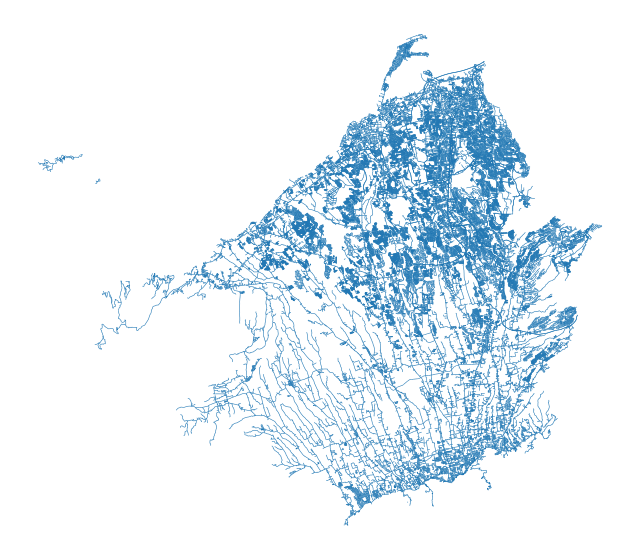

In [33]:
# Note the GeoJSONSeq: prefix so GDAL/pyogrio uses the right driver
gdf_cavite = gpd.read_file(
    os.path.join(OUT_DIR, "region-iv-a-calabarzon-cavite.geojsonl"),
    engine="pyogrio"
)

ax = gdf_cavite.plot(figsize=(8,8), linewidth=0.4)
ax.set_aspect("equal")
ax.axis("off")

plt.show()

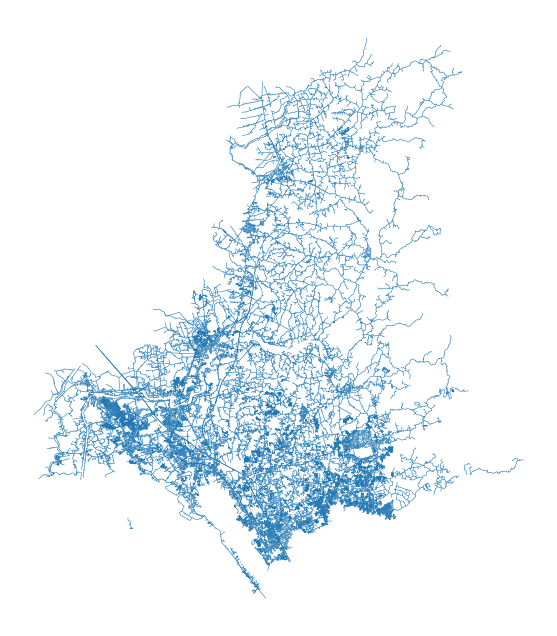

In [28]:
# Note the GeoJSONSeq: prefix so GDAL/pyogrio uses the right driver
gdf_bulacan = gpd.read_file(
    os.path.join(OUT_DIR, "region-iii-central-luzon-bulacan.geojsonl"),
    engine="pyogrio"
)

ax = gdf_bulacan.plot(figsize=(8,8), linewidth=0.4)
ax.set_aspect("equal")
ax.axis("off")

plt.show()

#### 2.2.3 All provinces

In [32]:
start_time = time.time()

writers = LRUWriters(OUT_DIR, max_open=MAX_OPEN_FILES)
handler = DriveHandler(
    prov=prov,
    writers=writers,
    drive_highways=DRIVE_HIGHWAYS,
    do_clip=DO_CLIP,
    whitelist=None                  # get ALL provinces
)
handler.apply_file(
    PBF_PATH,
    locations=True,
    idx="sparse_mmap_array"
)
writers.close_all()
handler.counts

end_time = (time.time() - start_time) / 60
print(f"Time elapsed for all provinces: {end_time:.2f} minutes")

Time elapsed for all provinces: 2.79 minutes


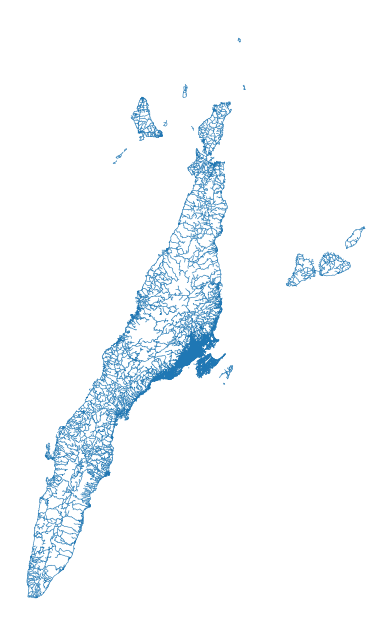

In [34]:
gdf_cebu = gpd.read_file(
    os.path.join(OUT_DIR, "region-vii-central-visayas-cebu.geojsonl"),
    engine="pyogrio"
)

ax = gdf_cebu.plot(figsize=(8,8), linewidth=0.4)
ax.set_aspect("equal")
ax.axis("off")

plt.show()

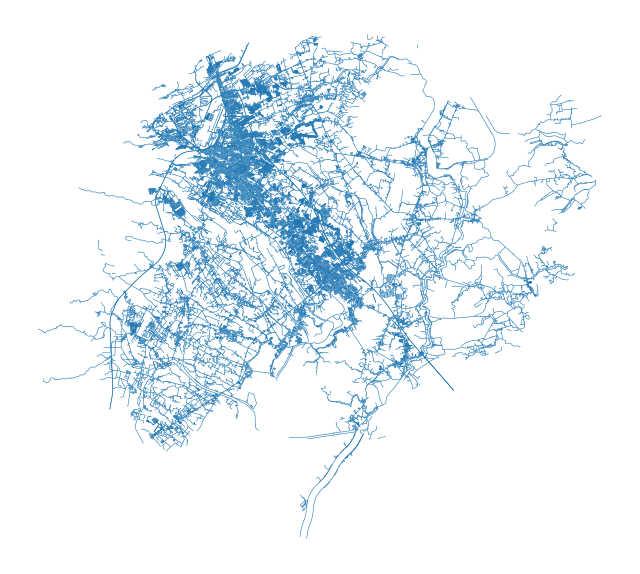

In [35]:
gdf_pampanga = gpd.read_file(
    os.path.join(OUT_DIR, "region-iii-central-luzon-pampanga.geojsonl"),
    engine="pyogrio"
)

ax = gdf_pampanga.plot(figsize=(8,8), linewidth=0.4)
ax.set_aspect("equal")
ax.axis("off")

plt.show()

### 2.3 Rename filenames

In [17]:
# CELL 1: Create the rename function
# ------------------------------------
def rename_to_psgc(prov_gdf, road_dir="output/province_road_networks", dry_run=True):
    """
    Rename province road network files from slugs to PSGC format.

    Parameters
    ----------
    prov_gdf : GeoDataFrame
        Province data with 'name' and 'prov_code' columns
    road_dir : str
        Directory containing .geojsonl files
    dry_run : bool
        If True, only print what would be renamed
    """
    # Build mapping: current_slug -> new_psgc_name
    slug_to_psgc = {}
    for idx, row in prov_gdf.iterrows():
        current_slug = slugify(row['name'])
        prov_code = row['prov_code']
        new_name = f"{prov_code[:2]}-{prov_code[2:5]}.geojsonl"
        slug_to_psgc[current_slug] = new_name

    # Rename files
    road_path = Path(road_dir)
    if not road_path.exists():
        print(f"ERROR: Directory not found: {road_dir}")
        return slug_to_psgc

    renamed_count = 0
    not_found = []

    print(f"\n{'=' * 80}")
    print(f"{'DRY RUN - ' if dry_run else ''}RENAMING FILES")
    print(f"{'=' * 80}\n")

    for old_file in sorted(road_path.glob("*.geojsonl")):
        old_slug = old_file.stem

        if old_slug in slug_to_psgc:
            new_name = slug_to_psgc[old_slug]
            new_path = old_file.parent / new_name

            if dry_run:
                print(f"  {old_file.name:65s} -> {new_name}")
            else:
                old_file.rename(new_path)
                print(f"✓ {old_file.name:65s} -> {new_name}")
            renamed_count += 1
        else:
            not_found.append(old_file.name)
            print(f"⚠ NO MAPPING: {old_file.name}")

    print(f"\n{'=' * 80}")
    print(f"{'DRY RUN - ' if dry_run else ''}SUMMARY")
    print(f"{'=' * 80}")
    print(f"  Files {'would be' if dry_run else ''} renamed: {renamed_count}")
    if not_found:
        print(f"  Files without mapping: {len(not_found)}")
        for fname in not_found:
            print(f"    - {fname}")
    print()

    return slug_to_psgc

In [18]:
# CELL 2: DRY RUN (preview changes)
# -----------------------------------
mapping = rename_to_psgc(prov['gdf'], OUT_DIR, dry_run=True)


DRY RUN - RENAMING FILES

  09-097.geojsonl                                                   -> 09-097.geojsonl
  13-074.geojsonl                                                   -> 13-074.geojsonl
  13-075.geojsonl                                                   -> 13-075.geojsonl
  13-076.geojsonl                                                   -> 13-076.geojsonl
  19-099.geojsonl                                                   -> 19-099.geojsonl
  bangsamoro-autonomous-region-in-muslim-mindanao-barmm-basilan.geojsonl -> 19-007.geojsonl
  bangsamoro-autonomous-region-in-muslim-mindanao-barmm-lanao-del-sur.geojsonl -> 19-036.geojsonl
  bangsamoro-autonomous-region-in-muslim-mindanao-barmm-maguindanao-del-norte.geojsonl -> 19-087.geojsonl
  bangsamoro-autonomous-region-in-muslim-mindanao-barmm-maguindanao-del-sur.geojsonl -> 19-088.geojsonl
  bangsamoro-autonomous-region-in-muslim-mindanao-barmm-sulu.geojsonl -> 19-066.geojsonl
  bangsamoro-autonomous-region-in-muslim-mindanao

In [19]:
# CELL 3: EXECUTE (after reviewing dry run output above)
# --------------------------------------------------------
# Uncomment the line below to actually rename the files:
# rename_to_psgc(prov['gdf'], OUT_DIR, dry_run=False)